# Detectors and Results

The NSQ engine provides four detector types, each capturing a different aspect
of the radiation reaching a surface:

| Detector | Result class | Records |
|---|---|---|
| `IrradianceDetector` | `IrradianceMap` | 2D spatial flux map |
| `FarFieldDetector` | `FarFieldPattern` | Angular (θ, φ) intensity distribution |
| `SpectralDetector` | `SpectralResult` | Per-wavelength irradiance map |
| `RayDatabaseDetector` | `RayDatabase` | Full phase-space record (x, y, z, L, M, N, flux, λ) |

Multiple detectors can be active simultaneously in the same scene. Each is
accumulated independently during the trace.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    PointSourceConfig, CollimatedSourceConfig,
    IrradianceDetectorConfig, FarFieldDetectorConfig,
    SpectralDetectorConfig, RayDatabaseConfig,
    LensConfig,
)

spec_green  = Spectrum.monochromatic(0.55)
spec_rgb    = Spectrum(
    wavelengths=np.array([0.45, 0.55, 0.65]),
    weights=np.array([1.0, 1.5, 1.0]),
)


## 1. IrradianceDetector

The most common detector. Records total flux deposited in each pixel of a
rectangular grid. The result `IrradianceMap.irradiance` is in **W/mm²**.

Use `IrradianceDetectorConfig(width, height, num_pixels_x, num_pixels_y)` to
configure it.

IrradianceMap shape: (128, 128)
Peak irradiance    : 0.0156 W/mm²
Total detected flux: 0.2853 W
Rays on detector   : 14,265


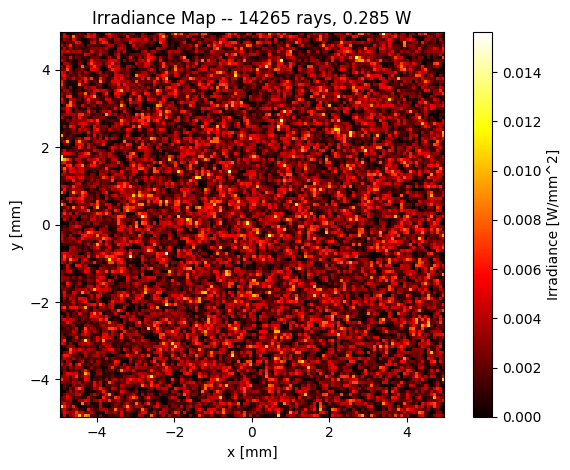

In [2]:
scene = NSQScene()
scene.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene.add_lens(
    'L', CoordinateSystem(z=0),
    LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7', front_aperture_radius=12.5),
)
scene.add_detector(
    'D_irr', CoordinateSystem(z=100),
    IrradianceDetectorConfig(width=10, height=10, num_pixels_x=128, num_pixels_y=128),
)

result = scene.trace(num_rays=50_000, seed=42)
irr_map = result.detectors['D_irr']

print(f"IrradianceMap shape: {irr_map.irradiance.shape}")
print(f"Peak irradiance    : {irr_map.irradiance.max():.4f} W/mm²")
print(f"Total detected flux: {irr_map.total_flux:.4f} W")
print(f"Rays on detector   : {irr_map.num_rays_hit:,}")

fig = irr_map.plot(cmap='hot')
plt.tight_layout()
plt.show()
plt.close(fig)

## 2. FarFieldDetector

Records the **angular distribution** of radiation. Instead of spatial position,
it bins each ray by its direction (θ, φ) at the detector surface.

The result `FarFieldPattern.intensity` is in **W/sr** and has shape
`(num_bins_theta, num_bins_phi)`. Note that `intensity` is per unit solid
angle, so summing it does *not* give a flux; use `FarFieldPattern.total_flux`
(in W) for the radiometric total.

The detector is placed at a finite location but uses a very large aperture
(1 km radius by default) so it captures essentially all forward-going rays.

FarFieldPattern shape: (45, 180)  (theta x phi)
Total flux recorded  : 0.9998 W
Peak intensity       : 1.88 W/sr


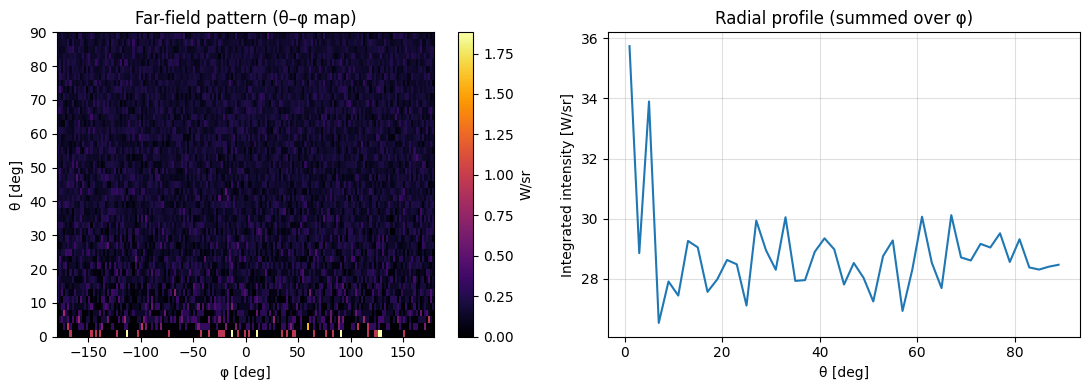

In [3]:
scene_ff = NSQScene()
# Isotropic hemisphere point source
scene_ff.add_source(
    'S', CoordinateSystem(z=0),
    PointSourceConfig(spectrum=spec_green, total_flux=1.0, half_angle_deg=90),
)
# FarFieldDetector captures the hemisphere at z > 0
scene_ff.add_detector(
    'FF', CoordinateSystem(z=100),
    FarFieldDetectorConfig(num_theta=45, num_phi=180),
)

result_ff = scene_ff.trace(num_rays=50_000, seed=42)
ff = result_ff.detectors['FF']

print(f"FarFieldPattern shape: {ff.intensity.shape}  (theta x phi)")
print(f"Total flux recorded  : {ff.total_flux:.4f} W")
print(f"Peak intensity       : {ff.intensity.max():.2f} W/sr")

# Sum over phi to get radial profile
intensity_radial = ff.intensity.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].pcolormesh(ff.phi, ff.theta, ff.intensity, cmap='inferno', shading='auto')
plt.colorbar(im, ax=axes[0], label='W/sr')
axes[0].set_xlabel('φ [deg]'); axes[0].set_ylabel('θ [deg]')
axes[0].set_title('Far-field pattern (θ–φ map)')

axes[1].plot(ff.theta, intensity_radial)
axes[1].set_xlabel('θ [deg]'); axes[1].set_ylabel('Integrated intensity [W/sr]')
axes[1].set_title('Radial profile (summed over φ)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
plt.close(fig)

## 3. SpectralDetector

Extends the irradiance detector with a third wavelength dimension. The result
`SpectralResult.irradiance` has shape `(ny, nx, n_lambda)` in W/mm².

Add a `SpectralDetector` via `SpectralDetectorConfig`. Its binning range
(`wl_min`, `wl_max`) is given in **nm** with `num_bins` wavelength bins:

SpectralResult irradiance shape: (64, 64, 20)  (ny, nx, nlambda)
Wavelength centres (nm): [445.5 456.5 467.5 478.5 489.5 500.5 511.5 522.5 533.5 544.5 555.5 566.5
 577.5 588.5 599.5 610.5 621.5 632.5 643.5 654.5]


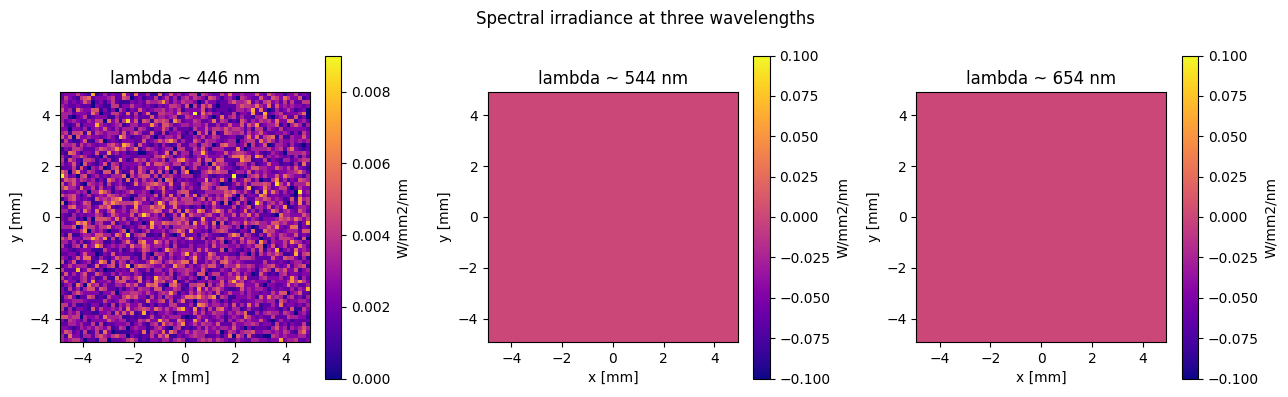

In [4]:
# SpectralDetector bins flux by wavelength. The binning range is given in nm.
scene_sp = NSQScene()
scene_sp.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_rgb, total_flux=1.0, aperture_radius=10.0),
)
scene_sp.add_lens(
    'L', CoordinateSystem(z=0),
    LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7', front_aperture_radius=12.5),
)
scene_sp.add_detector(
    'SD', CoordinateSystem(z=100),
    SpectralDetectorConfig(width=10, height=10, num_pixels_x=64, num_pixels_y=64,
                           wl_min=440, wl_max=660, num_bins=20),
)

result_sp = scene_sp.trace(num_rays=50_000, seed=42)
sp_result = result_sp.detectors['SD']

print(f"SpectralResult irradiance shape: {sp_result.irradiance.shape}  (ny, nx, nlambda)")
print(f"Wavelength centres (nm): {sp_result.wavelengths.round(1)}")

# Plot irradiance at three wavelength bins (wavelengths are in nm)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
wl_targets = [450, 550, 650]
for ax, wl in zip(axes, wl_targets):
    idx = int(np.argmin(np.abs(sp_result.wavelengths - wl)))
    E_wl = sp_result.irradiance[:, :, idx]
    im = ax.imshow(E_wl, origin='lower', cmap='plasma', aspect='equal',
                   extent=[sp_result.x_coords[0], sp_result.x_coords[-1],
                            sp_result.y_coords[0], sp_result.y_coords[-1]])
    plt.colorbar(im, ax=ax, label='W/mm2/nm')
    ax.set_title(f'lambda ~ {sp_result.wavelengths[idx]:.0f} nm')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Spectral irradiance at three wavelengths', fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)


## 4. RayDatabaseDetector

Stores complete phase-space information for every ray that hits the detector:
position (x, y, z), direction cosines (L, M, N), flux, and wavelength. This
enables post-trace analysis beyond what the other detectors support.

The `RayDatabase.to_dataframe()` method converts the data to a pandas DataFrame
for convenient analysis.

Rays stored: 5,736
Total flux : 0.2868 W


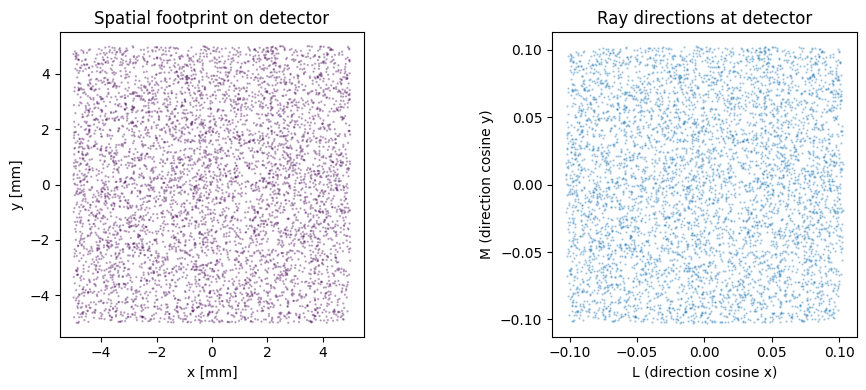

In [5]:
scene_rdb = NSQScene()
scene_rdb.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene_rdb.add_lens(
    'L', CoordinateSystem(z=0),
    LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7', front_aperture_radius=12.5),
)
scene_rdb.add_detector(
    'RDB', CoordinateSystem(z=100),
    RayDatabaseConfig(width=10, height=10),
)

result_rdb = scene_rdb.trace(num_rays=20_000, seed=42)
db = result_rdb.detectors['RDB']

print(f"Rays stored: {db.num_rays:,}")
print(f"Total flux : {db.flux.sum():.4f} W")

# Phase-space scatter plot: x vs y (spatial footprint)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(db.x, db.y, s=0.5, alpha=0.3, c=db.flux, cmap='viridis')
axes[0].set_xlabel('x [mm]'); axes[0].set_ylabel('y [mm]')
axes[0].set_title('Spatial footprint on detector')
axes[0].set_aspect('equal')

# Direction cosine distribution
axes[1].scatter(db.L, db.M, s=0.5, alpha=0.3)
axes[1].set_xlabel('L (direction cosine x)'); axes[1].set_ylabel('M (direction cosine y)')
axes[1].set_title('Ray directions at detector')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()
plt.close(fig)


## 5. Multiple Detectors in One Scene

Detectors are passive — adding more does not slow down ray generation, only the
recording step. You can place several detectors to analyse the beam at different
planes simultaneously:

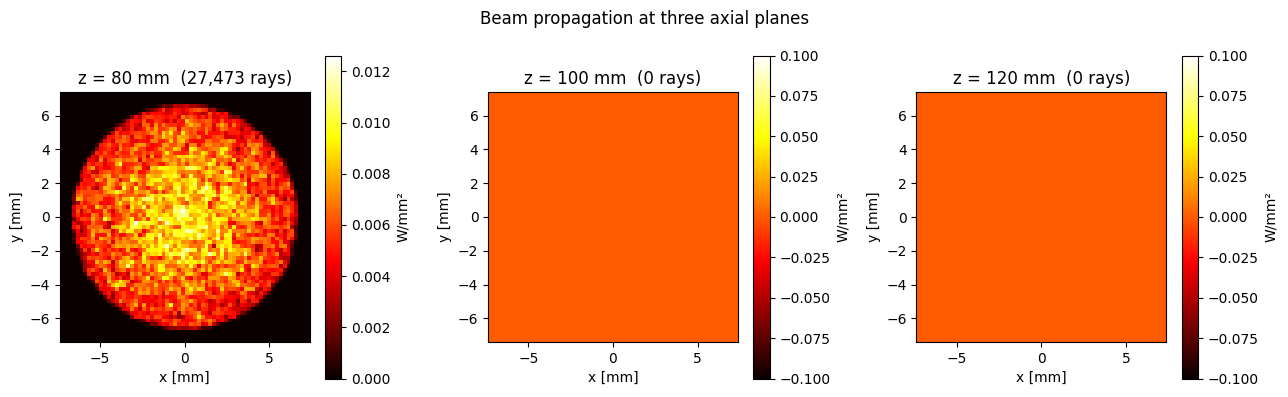

In [6]:
scene_multi = NSQScene()
scene_multi.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene_multi.add_lens(
    'L', CoordinateSystem(z=0),
    LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7', front_aperture_radius=12.5),
)
# Three detectors at different z planes
for z, name in [(80, 'D_80'), (100, 'D_100'), (120, 'D_120')]:
    scene_multi.add_detector(
        name, CoordinateSystem(z=z),
        IrradianceDetectorConfig(width=15, height=15, num_pixels_x=64, num_pixels_y=64),
    )

result_multi = scene_multi.trace(num_rays=30_000, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, ['D_80', 'D_100', 'D_120']):
    irr = result_multi.detectors[name]
    im = ax.imshow(irr.irradiance, origin='lower', cmap='hot', aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                            irr.y_coords[0], irr.y_coords[-1]])
    plt.colorbar(im, ax=ax, label='W/mm²')
    z = int(name.split('_')[1])
    ax.set_title(f'z = {z} mm  ({irr.num_rays_hit:,} rays)')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Beam propagation at three axial planes', fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)

## Summary

- `IrradianceDetector` → `IrradianceMap`: 2D flux map, `irradiance` in W/mm²
- `FarFieldDetector` → `FarFieldPattern`: angular distribution, `intensity` in W/sr
- `SpectralDetector` → `SpectralResult`: per-wavelength 2D map; binning range (`wl_min`/`wl_max`/`num_bins`) in **nm**
- `RayDatabaseDetector` → `RayDatabase`: full phase-space record; use `.to_dataframe()` for analysis
- Multiple detectors can be placed simultaneously — no ray count penalty